# How p-values Fail Production ML Systems
Every ML engineer eventually learns about feature drift monitoring. The common approach is simple: compare live production data with the original training data using a statistical test like the Kolmogorov–Smirnov (KS) test. If the p-value drops below 0.05, the system flags drift and triggers retraining. On paper, this sounds rigorous and reliable.

The problem appears when these systems operate at production scale. Modern ML pipelines often process millions of records every day, and with sample sizes that large, even tiny and completely harmless changes in feature distributions become “statistically significant.” A shift so small that it has no real impact on model predictions can still produce a near-zero p-value and repeatedly trigger false alarms.

In large-scale systems monitoring hundreds of features, this creates a practical nightmare: retraining pipelines fire constantly, engineers lose trust in drift alerts, and monitoring becomes noisy instead of useful. In this article, we will see why p-value–based drift detection breaks down in production ML systems, explore the mathematics behind this behavior, and replace it with more practical magnitude-based metrics like Population Stability Index (PSI) and Wasserstein distance.

## Setting up the dependencies


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import wasserstein_distance

np.random.seed(42)

## Helper Functions
This code block implements and compares three different approaches for detecting feature drift between training data and live production data. The calculate_psi function measures how much the distribution has shifted using the Population Stability Index (PSI), while ks_test performs the traditional Kolmogorov–Smirnov statistical test to compute a p-value. The main trigger_analysis function runs all three drift detection methods — KS test, PSI, and Wasserstein distance — on the same pair of distributions, applies predefined thresholds, and prints a side-by-side comparison showing whether each method would trigger retraining. This makes it easy to directly observe how p-value–based methods can overreact at large sample sizes, while magnitude-based metrics focus on whether the shift is practically meaningful.

In [ ]:
def calculate_psi(expected, actual, buckets=20):
    """
    Population Stability Index (PSI).

    Using 20 bins (vs the common default of 10) gives better resolution
    for continuous features — the standard finance default of 10 was
    designed for coarsely-binned credit score bands.

    PSI < 0.10  → stable, no action needed
    PSI 0.10–0.20 → moderate drift, monitor closely
    PSI > 0.20  → major drift, retrain
    """
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    # Avoid duplicate edges that can arise with discrete data
    breakpoints = np.unique(breakpoints)

    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts   = np.histogram(actual,   bins=breakpoints)[0]

    # Convert to proportions; add epsilon to prevent log(0)
    eps = 1e-8
    expected_pct = expected_counts / len(expected) + eps
    actual_pct   = actual_counts   / len(actual)   + eps

    psi = np.sum((expected_pct - actual_pct) * np.log(expected_pct / actual_pct))
    return psi


def ks_test(train, live):
    """Returns (D statistic, p-value) from a two-sample KS test."""
    stat, pval = stats.ks_2samp(train, live)
    return stat, pval


def trigger_analysis(train, live, label=""):
    """Run both approaches and compare their decisions."""
    n = len(train)

    # --- KS test ---
    ks_stat, ks_pval = ks_test(train, live)
    ks_trigger = ks_pval < 0.05

    # --- PSI ---
    psi = calculate_psi(train, live)
    psi_trigger = psi > 0.20

    # --- Wasserstein distance ---
    w_dist = wasserstein_distance(train, live)
    # Threshold: calibrated to ~0.05 std-deviation shift having no practical impact
    w_trigger = w_dist > 0.05

    print(f"\n{'='*55}")
    print(f"  {label}  (N = {n:,})")
    print(f"{'='*55}")
    print(f"  {'Metric':<28} {'Value':>10}  {'Retrain?':>10}")
    print(f"  {'-'*50}")
    print(f"  {'KS p-value':<28} {ks_pval:>10.6f}  {'🔴 YES' if ks_trigger else '🟢 NO':>10}")
    print(f"  {'PSI':<28} {psi:>10.4f}  {'🔴 YES' if psi_trigger else '🟢 NO':>10}")
    print(f"  {'Wasserstein Distance':<28} {w_dist:>10.5f}  {'🔴 YES' if w_trigger else '🟢 NO':>10}")
    print(f"{'='*55}")

    return dict(ks_pval=ks_pval, ks_trigger=ks_trigger,
                psi=psi,         psi_trigger=psi_trigger,
                w_dist=w_dist,   w_trigger=w_trigger)

# Scenario A: Trivial Shift at Scale
To demonstrate the problem, we generate two datasets with one million samples each. The training data follows a standard normal distribution, while the live data is almost identical except for an extremely tiny shift in the mean — just 0.005 standard deviations. In practice, this change is far too small to affect model predictions in any meaningful way. We intentionally use one million samples because large-scale production systems regularly process this amount of data, and large sample sizes are exactly where p-value–based drift detection begins to fail.

When we run the KS test, PSI, and Wasserstein distance on these datasets, the KS test produces a p-value below 0.05 and incorrectly signals drift, even though the shift is practically harmless. This happens because very large sample sizes give the test enough statistical power to detect even microscopic differences. In contrast, PSI and Wasserstein distance remain well below their thresholds and correctly conclude that no retraining is needed. This example highlights the core issue: p-values answer whether two distributions are different, while production monitoring should focus on whether the difference is large enough to actually matter.

In [ ]:
print("\n" + "="*55)
print("  SCENARIO A: Trivial Shift at High Volume")
print("  Training: N(0, 1)  |  Live: N(0.005, 1)")
print("="*55)
print("  Practical impact: essentially zero.")
print("  A feature shift of 0.005 std-devs changes model")
print("  output probability by < 0.001%.\n")

train_A = np.random.normal(0,     1, 1_000_000)
live_A  = np.random.normal(0.005, 1, 1_000_000)

results_A = trigger_analysis(train_A, live_A, "Scenario A — Trivial Shift, N=1M")

print("\n  ⚠  The KS test triggers a retraining job that costs")
print("     thousands of dollars for a completely stable model.\n")


  SCENARIO A: Trivial Shift at High Volume
  Training: N(0, 1)  |  Live: N(0.005, 1)
  Practical impact: essentially zero.
  A feature shift of 0.005 std-devs changes model
  output probability by < 0.001%.


  Scenario A — Trivial Shift, N=1M  (N = 1,000,000)
  Metric                            Value    Retrain?
  --------------------------------------------------
  KS p-value                     0.000182       🔴 YES
  PSI                              0.0001        🟢 NO
  Wasserstein Distance            0.00642        🟢 NO

  ⚠  The KS test triggers a retraining job that costs
     thousands of dollars for a completely stable model.



# SCENARIO B: Real Actionable Drift
We now create a scenario with real and meaningful drift. The training data again follows a standard normal distribution, but the live data has both a shifted mean and a larger spread. This simulates what often happens in production systems when user behavior, market conditions, or incoming data patterns genuinely change over time. Unlike the previous example, this level of drift is large enough to noticeably affect model predictions and calibration.

When we run the three drift detection methods, all of them correctly trigger retraining. The KS test again returns an extremely small p-value, but it only tells us that a difference exists — not how large or important it is. PSI and Wasserstein distance provide much more useful information because their values reflect the actual magnitude of the drift. Compared to the earlier scenario, where only the KS test raised a false alarm, PSI and Wasserstein now correctly identify this as a meaningful distribution shift. This contrast highlights why magnitude-based metrics are far more practical for production ML monitoring systems.

In [ ]:
print("\n" + "="*55)
print("  SCENARIO B: Real Actionable Drift")
print("  Training: N(0, 1)  |  Live: N(0.4, 1.3)")
print("="*55)
print("  Practical impact: significant.\n")

train_B = np.random.normal(0,   1.0, 1_000_000)
live_B  = np.random.normal(0.4, 1.3, 1_000_000)

results_B = trigger_analysis(train_B, live_B, "Scenario B — Real Drift, N=1M")


  SCENARIO B: Real Actionable Drift
  Training: N(0, 1)  |  Live: N(0.4, 1.3)
  Practical impact: significant.


  Scenario B — Real Drift, N=1M  (N = 1,000,000)
  Metric                            Value    Retrain?
  --------------------------------------------------
  KS p-value                     0.000000       🔴 YES
  PSI                              0.2178       🔴 YES
  Wasserstein Distance            0.42520       🔴 YES


# The Scaling Law Visualised
This code creates two side-by-side visualizations to compare how the KS test and PSI behave as sample size increases. First, it generates a range of sample sizes from 100 to 10 million and computes the KS critical threshold for each size using the standard KS scaling formula. It then plots this against the actual KS statistic produced by a very small fixed distribution shift, highlighting the point where the shift begins triggering false alarms. In the second plot, the code repeatedly generates synthetic datasets with both trivial drift and real drift across different sample sizes, computes their PSI scores, and visualizes how PSI remains relatively stable regardless of N.

This figure demonstrates the fundamental difference between p-value–based drift detection and magnitude-based metrics. The left panel shows how the KS test threshold rapidly shrinks as sample size increases, eventually becoming so sensitive that even a tiny and practically meaningless shift triggers constant false alarms at production-scale volumes. The right panel contrasts this with PSI, which remains stable across different sample sizes: trivial shifts consistently stay near zero, while genuine drift consistently remains above the retraining threshold. Together, the two plots highlight why KS-based monitoring breaks at scale, while magnitude-based metrics like PSI produce stable and actionable drift decisions.

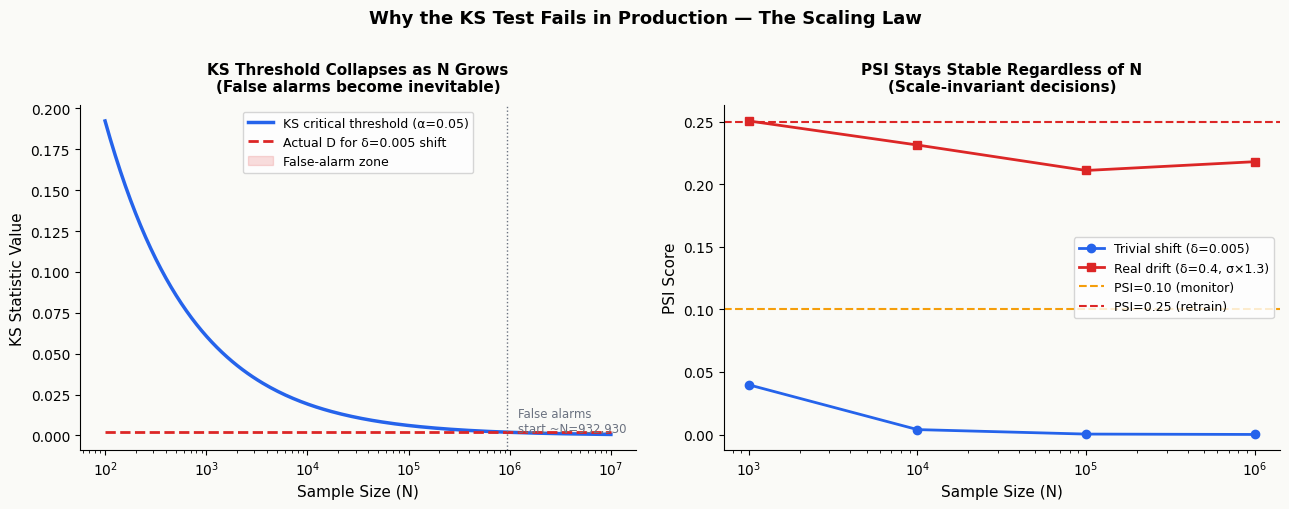

  Saved → scaling_law.png


In [ ]:
sample_sizes = np.logspace(2, 7, 200)          # 100 → 10,000,000

# KS critical value at α=0.05, equal sample sizes n=m=N
ks_critical  = 1.36 * np.sqrt(2 / sample_sizes)

# Actual D for a shift of δ=0.005 std-devs: D ≈ δ/√(2π)
delta        = 0.005
actual_D     = delta / np.sqrt(2 * np.pi) * np.ones_like(sample_sizes)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#FAFAF7")

# ---- Left: KS threshold collapse ----
ax = axes[0]
ax.set_facecolor("#FAFAF7")

ax.plot(sample_sizes, ks_critical, color="#2563EB", lw=2.5, label="KS critical threshold (α=0.05)")
ax.plot(sample_sizes, actual_D,    color="#DC2626", lw=2,   linestyle="--",
        label=f"Actual D for δ={delta} shift")
ax.fill_between(sample_sizes, ks_critical, actual_D,
                where=(actual_D > ks_critical), alpha=0.15, color="#DC2626",
                label="False-alarm zone")

# Mark the crossing point
cross_idx = np.argmin(np.abs(ks_critical - actual_D[0]))
cross_N   = sample_sizes[cross_idx]
ax.axvline(cross_N, color="#6B7280", lw=1, linestyle=":")
ax.text(cross_N * 1.3, actual_D[0] * 1.1,
        f"False alarms\nstart ~N={int(cross_N):,}",
        fontsize=8.5, color="#6B7280")

ax.set_xscale("log")
ax.set_xlabel("Sample Size (N)", fontsize=11)
ax.set_ylabel("KS Statistic Value", fontsize=11)
ax.set_title("KS Threshold Collapses as N Grows\n(False alarms become inevitable)",
             fontsize=11, fontweight="bold", pad=10)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.set_facecolor("#FAFAF7")

# ---- Right: PSI is scale-invariant ----
ax2 = axes[1]
ax2.set_facecolor("#FAFAF7")

psi_trivial = []
psi_real    = []

for n in [1_000, 10_000, 100_000, 1_000_000]:
    tr = np.random.normal(0,     1.0, n)
    psi_trivial.append(calculate_psi(tr, np.random.normal(0.005, 1.0, n)))
    psi_real.append(calculate_psi(   tr, np.random.normal(0.4,   1.3, n)))

ns = [1_000, 10_000, 100_000, 1_000_000]
ax2.plot(ns, psi_trivial, "o-", color="#2563EB", lw=2,   label="Trivial shift (δ=0.005)")
ax2.plot(ns, psi_real,    "s-", color="#DC2626", lw=2,   label="Real drift (δ=0.4, σ×1.3)")
ax2.axhline(0.10, color="#F59E0B", lw=1.5, linestyle="--", label="PSI=0.10 (monitor)")
ax2.axhline(0.25, color="#DC2626", lw=1.5, linestyle="--", label="PSI=0.25 (retrain)")

ax2.set_xscale("log")
ax2.set_xlabel("Sample Size (N)", fontsize=11)
ax2.set_ylabel("PSI Score", fontsize=11)
ax2.set_title("PSI Stays Stable Regardless of N\n(Scale-invariant decisions)",
              fontsize=11, fontweight="bold", pad=10)
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Why the KS Test Fails in Production — The Scaling Law",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("scaling_law.png", dpi=150, bbox_inches="tight",
            facecolor="#FAFAF7")
plt.show()
print("  Saved → scaling_law.png")

# Distribution Visualisation
(ECDFs) for two drift scenarios: a trivial shift and a genuinely drifted distribution. For each scenario, it sorts a subset of the training and live data, computes their cumulative probabilities, and plots the ECDF curves on the same axes. The first panel visualizes a tiny shift that is almost impossible to distinguish visually, while the second panel shows a much larger and clearly noticeable drift.

This figure visualizes the difference between trivial and meaningful drift using empirical cumulative distribution functions (ECDFs). In the trivial-shift scenario, the training and live ECDF curves are almost identical, showing a difference so small that it is barely visible, yet the KS test still flags drift because of the massive sample size. In contrast, the real-drift scenario shows a clear separation between the curves, reflecting both the shifted mean and increased variance of the live distribution. Together, the two panels highlight the main limitation of the KS test: it treats both tiny and substantial differences as equally significant, while magnitude-based metrics like PSI and Wasserstein distance better capture whether the drift is actually meaningful.

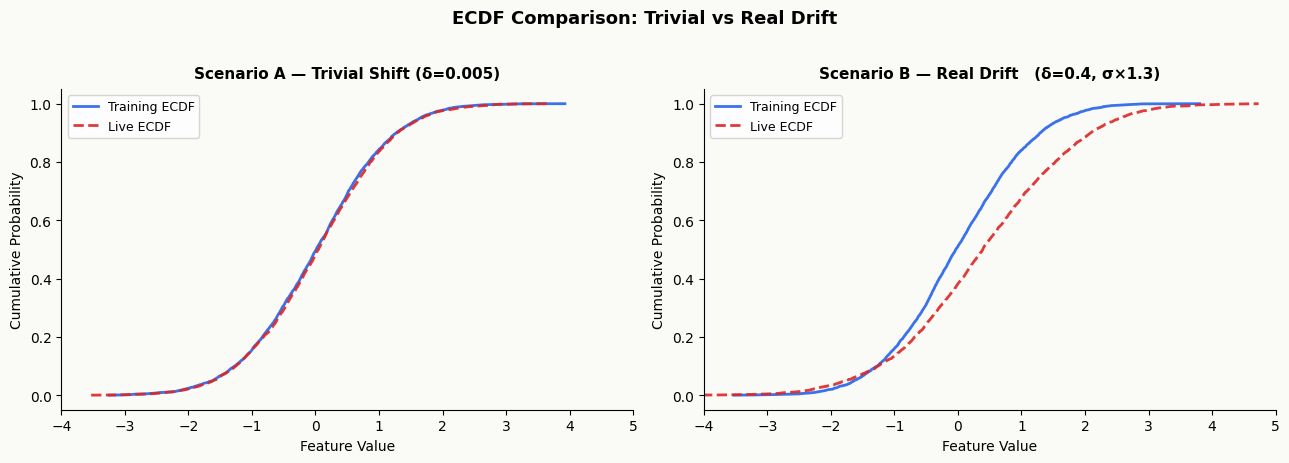

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("#FAFAF7")

x_range = np.linspace(-4, 5, 1_000)

for ax, (train, live, title, shift) in zip(
    axes,
    [
        (train_A, live_A, "Scenario A — Trivial Shift (δ=0.005)",  "0.005 std-devs"),
        (train_B, live_B, "Scenario B — Real Drift   (δ=0.4, σ×1.3)", "0.4 std-devs + wider"),
    ]
):
    ax.set_facecolor("#FAFAF7")

    # Empirical CDFs
    sorted_tr   = np.sort(train[:5_000])   # subsample for speed
    sorted_live = np.sort(live[:5_000])
    n = len(sorted_tr)

    ax.plot(sorted_tr,   np.arange(1, n+1)/n, color="#2563EB", lw=2,
            label="Training ECDF",   alpha=0.9)
    ax.plot(sorted_live, np.arange(1, n+1)/n, color="#DC2626", lw=2,
            linestyle="--", label="Live ECDF", alpha=0.9)

    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Feature Value", fontsize=10)
    ax.set_ylabel("Cumulative Probability", fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(-4, 5)

plt.suptitle("ECDF Comparison: Trivial vs Real Drift", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("ecdf_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="#FAFAF7")
plt.show()

## The Full Production-Safe Drift Detector
The DriftDetector class packages the drift detection logic into a reusable production-style workflow. It follows a simple fit/score pattern: .fit() stores the training distribution as the baseline, while .report() evaluates incoming live data against it. The detector combines two magnitude-based metrics — PSI (threshold = 0.15) and Wasserstein distance (threshold = 0.05) — using OR logic, meaning retraining is triggered if either metric detects meaningful drift. This design makes the system more robust because PSI captures changes in distribution proportions, while Wasserstein measures the overall transport distance between distributions.

The three demo cases show how the detector behaves in practice. In the trivial-shift scenario, PSI is only 0.00009 and Wasserstein distance is 0.00466, both far below their thresholds, so the detector correctly avoids a false alarm. In the real-drift scenario, PSI rises to 0.21502 and Wasserstein distance to 0.42477, clearly exceeding the thresholds and correctly triggering retraining. The most interesting case is the borderline seasonal drift scenario, where PSI remains low at 0.00959, but Wasserstein distance reaches 0.08112, crossing its threshold. Even though PSI alone would miss this drift, the combined logic still flags retraining, showing why using multiple magnitude-based metrics together is more reliable for production ML monitoring.

In [ ]:
class DriftDetector:
    """
    Production-safe drift detector using magnitude metrics.

    Parameters
    ----------
    psi_threshold : float
        Trigger retraining if PSI exceeds this value (default 0.15).
        Lower than the classic 0.20 finance default because we use 20 bins
        instead of 10 — finer bins produce higher raw PSI for the same shift.
    wasserstein_threshold : float
        Trigger retraining if Wasserstein distance exceeds this value.
        Calibrate against historical model-performance degradation data.
    buckets : int
        Number of bins for PSI calculation.
    """

    def __init__(self, psi_threshold=0.15, wasserstein_threshold=0.05, buckets=20):
        self.psi_threshold          = psi_threshold
        self.wasserstein_threshold  = wasserstein_threshold
        self.buckets                = buckets
        self.baseline               = None

    def fit(self, baseline_data: np.ndarray):
        """Store the training baseline distribution."""
        self.baseline = baseline_data
        print(f"  Baseline fitted on {len(baseline_data):,} samples.")
        print(f"  Baseline stats — mean: {baseline_data.mean():.4f}, "
              f"std: {baseline_data.std():.4f}")

    def score(self, live_data: np.ndarray) -> dict:
        """
        Compute drift metrics between baseline and live data.
        Returns a dict with scores and a boolean trigger decision.
        """
        if self.baseline is None:
            raise RuntimeError("Call .fit() with baseline data first.")

        psi    = calculate_psi(self.baseline, live_data, self.buckets)
        w_dist = wasserstein_distance(self.baseline, live_data)

        psi_trigger = psi    > self.psi_threshold
        w_trigger   = w_dist > self.wasserstein_threshold

        # OR logic: either metric firing is sufficient.
        # Rationale: PSI and Wasserstein are sensitive to different
        # aspects of distribution shift (binned proportions vs. transport
        # cost). Real drift will usually trip both, but a single strong
        # signal is already informative enough to act on.
        # Use AND if your retraining pipeline is very expensive and you
        # can tolerate missing early-stage drift.
        should_retrain = psi_trigger or w_trigger

        return {
            "psi":               round(psi,    5),
            "wasserstein":       round(w_dist, 5),
            "psi_trigger":       psi_trigger,
            "wasserstein_trigger": w_trigger,
            "should_retrain":    should_retrain,
        }

    def report(self, live_data: np.ndarray):
        """Human-readable drift report."""
        result = self.score(live_data)
        n_live = len(live_data)

        print(f"\n{'─'*50}")
        print(f"  Drift Detection Report  (N_live = {n_live:,})")
        print(f"{'─'*50}")
        print(f"  PSI             : {result['psi']:.5f}  "
              f"(threshold {self.psi_threshold})  "
              f"{'🔴 DRIFT' if result['psi_trigger'] else '🟢 STABLE'}")
        print(f"  Wasserstein     : {result['wasserstein']:.5f}  "
              f"(threshold {self.wasserstein_threshold})  "
              f"{'🔴 DRIFT' if result['wasserstein_trigger'] else '🟢 STABLE'}")
        print(f"{'─'*50}")
        decision = "🔴  RETRAIN" if result["should_retrain"] else "🟢  NO ACTION"
        print(f"  Decision        : {decision}")
        print(f"{'─'*50}\n")

        return result


# ---- Demo ----
print("\n  ── DriftDetector Demo ──\n")

detector = DriftDetector(psi_threshold=0.15, wasserstein_threshold=0.05)
detector.fit(np.random.normal(0, 1, 500_000))

print("\n  [Case 1] Trivial shift — should NOT trigger retraining")
detector.report(np.random.normal(0.005, 1.0, 1_000_000))

print("\n  [Case 2] Real actionable drift — should trigger retraining")
detector.report(np.random.normal(0.4, 1.3, 1_000_000))

print("\n  [Case 3] Seasonal shift, borderline — Wasserstein fires, PSI stable → retrain")
detector.report(np.random.normal(0.08, 1.05, 1_000_000))


  ── DriftDetector Demo ──

  Baseline fitted on 500,000 samples.
  Baseline stats — mean: 0.0007, std: 1.0005

  [Case 1] Trivial shift — should NOT trigger retraining

──────────────────────────────────────────────────
  Drift Detection Report  (N_live = 1,000,000)
──────────────────────────────────────────────────
  PSI             : 0.00009  (threshold 0.15)  🟢 STABLE
  Wasserstein     : 0.00466  (threshold 0.05)  🟢 STABLE
──────────────────────────────────────────────────
  Decision        : 🟢  NO ACTION
──────────────────────────────────────────────────


  [Case 2] Real actionable drift — should trigger retraining

──────────────────────────────────────────────────
  Drift Detection Report  (N_live = 1,000,000)
──────────────────────────────────────────────────
  PSI             : 0.21502  (threshold 0.15)  🔴 DRIFT
  Wasserstein     : 0.42477  (threshold 0.05)  🔴 DRIFT
──────────────────────────────────────────────────
  Decision        : 🔴  RETRAIN
────────────────────────────

{'psi': np.float64(0.00959),
 'wasserstein': np.float64(0.08112),
 'psi_trigger': np.False_,
 'wasserstein_trigger': np.True_,
 'should_retrain': np.True_}